## Zomato Data Analysis

In [1]:
# importing necessary libraries

import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("Zomato_data.csv")
df.head(3)

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [4]:
df.rename(columns={"listed_in(type)":"Restaurent_Type"},inplace=True)
df.head(2)

,name,online_order,book_table,rate,votes,approx_cost(for two people),Restaurent_Type
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet


In [5]:
# checking if any columns contains null values

df.isnull().sum()

name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
approx_cost(for two people)    0
Restaurent_Type                0
dtype: int64

In [6]:
# checking for any duplicated records
df.duplicated().sum()

0

### Data Preprocessing

In [7]:
# converting the values corresponding to rate column to floating point by removing denominator
# 4.1/5
df["rate"] = df["rate"].apply(lambda x : float(x.split('/')[0]))
df.head(4)


,name,online_order,book_table,rate,votes,approx_cost(for two people),Restaurent_Type
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet


In [8]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   name                         148 non-null    object 
 1   online_order                 148 non-null    object 
 2   book_table                   148 non-null    object 
 3   rate                         148 non-null    float64
 4   votes                        148 non-null    int64  
 5   approx_cost(for two people)  148 non-null    int64  
 6   Restaurent_Type              148 non-null    object 
dtypes: float64(1), int64(2), object(4)
memory usage: 8.2+ KB


### solving the business questions


## 1) What type of restaurant do the majority of customers order from?


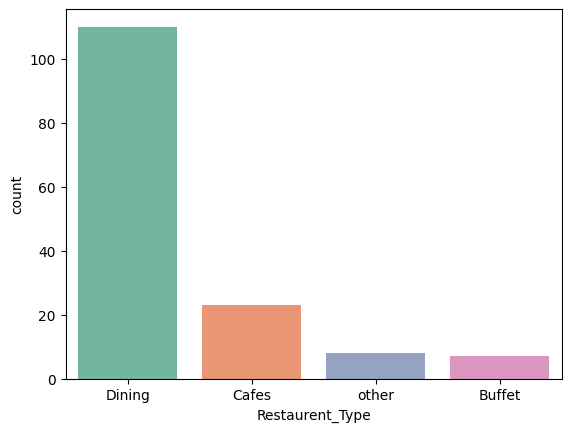

In [9]:
sns.countplot(x = "Restaurent_Type",data = df,order=df["Restaurent_Type"].value_counts().index, palette="Set2")
plt.show()

- conclusion : Majority of the customers place orders from "Dining Restaurent"

## 2 How many votes has each type of restaurant received from customers?

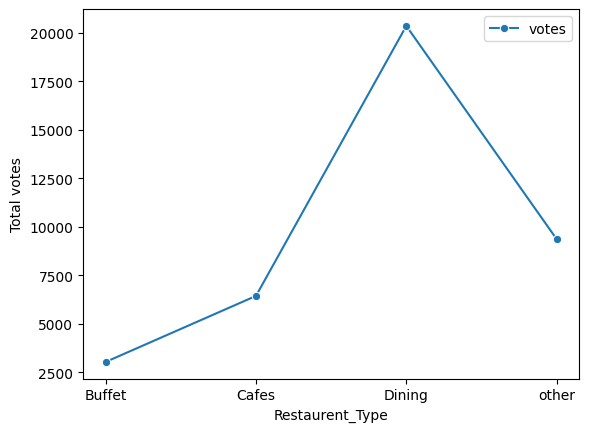

In [10]:
# Total vote count by each restaureant

# type(df.groupby("Restaurent_Type")['votes'].sum()) ==> return series 
total_votes_per_restaurent = df.groupby("Restaurent_Type")['votes'].sum()
df_sum = pd.DataFrame(total_votes_per_restaurent)
df_sum
sns.lineplot(data =df_sum, markers='o')
plt.ylabel("Total votes")
plt.show()


- Total votes by restaurent

### What are the ratings that the majority of restaurants have received?

<Axes: >

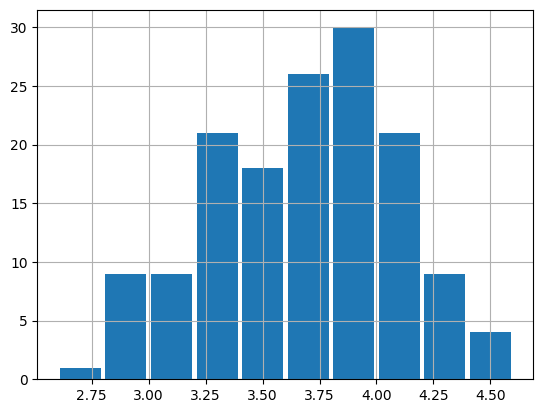

In [11]:
df["rate"].hist(rwidth=0.9)



- Therefore majority of the rastaurents received the reating  b/w 3.25 to 4.25

### 4)Zomato has observed that most couples order most of their food online. What is their average spending on each order?

In [12]:
round(df[df["online_order"] == "Yes"]["approx_cost(for two people)"].mean(),2)

510.34

- The average spending of the couples through online orders is 510.34

### 5) Which mode (online or offline) has received the maximum rating?


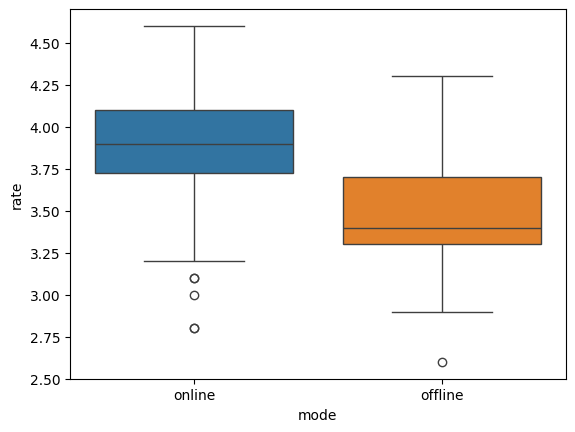

In [13]:
df["mode"] = df["online_order"].apply(lambda x: "online" if x == "Yes" else "offline")

sns.boxplot( x = "mode",y = "rate", data = df,hue = df["mode"])
plt.show()

- offline orders recieved minimum rating when compared to online orders

### Which type of restaurant received more offline orders, so that Zomato can provide those customers with some good offers?

<Axes: xlabel='Restaurent_Type', ylabel='count'>

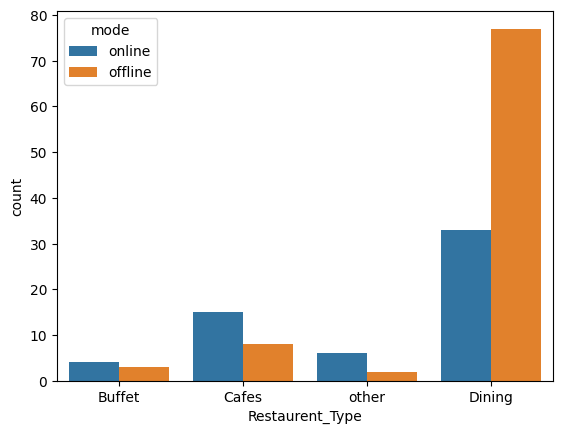

In [20]:
sns.countplot(x="Restaurent_Type", data = df , hue = df["mode"])

In [58]:
df[df["Restaurent_Type"] == "Dining"]["mode"].value_counts()

mode
offline    77
online     33
Name: count, dtype: int64

<Axes: xlabel='mode', ylabel='Restaurent_Type'>

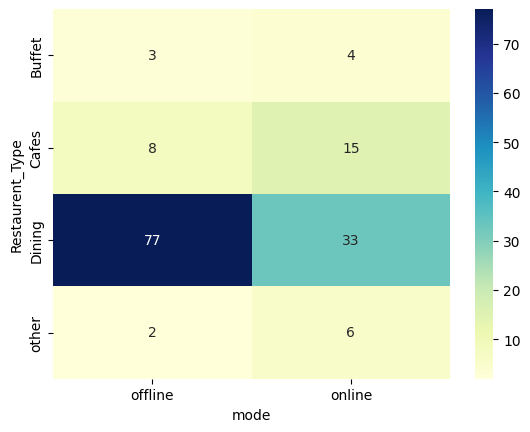

In [70]:
pivot__table = df.pivot_table(index="Restaurent_Type",columns=df["mode"],aggfunc="count",values="mode")
sns.heatmap(data = pivot__table,annot=True,fmt='d',cmap='YlGnBu')

- Therefore Dining Restaturent received more number of offline orders